In [8]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from sklearn import metrics

In [ ]:
data_dir = "processed_data"
output_model_path = "model_gru_60.h5"

test_size = 0.10
random_state = 42

# Параметры обучения
epochs = 400
dropout_rate=0.5
frames = 20  
num_features = 126 


In [ ]:
actions = []
for item in os.listdir(data_dir):
    item_path = os.path.join(data_dir, item)
    if os.path.isdir(item_path):
        actions.append(item)

actions = np.array(actions)

if len(actions) == 0:
    print(f"ОШИБКА: В {data_dir} не найдено поддиректорий со словами.")

print(f"Найдено {len(actions)} слов.")

Найдено 60 слов.


In [11]:
first_word_dir = os.path.join(data_dir, actions[0])
sequences_dirs = [d for d in os.listdir(first_word_dir) if os.path.isdir(os.path.join(first_word_dir, d))]
sequences = len(sequences_dirs)

print(f"Найдено {len(actions)} слов с {sequences} последовательностями по {frames} кадров.")

label_map = {label: num for num, label in enumerate(actions)}

landmarks, labels = [], []
len(label_map)

Найдено 60 слов с 20 последовательностями по 20 кадров.


60

In [ ]:
for action in actions:
    action_dir = os.path.join(data_dir, action)
    sequence_dirs = [d for d in os.listdir(action_dir) if os.path.isdir(os.path.join(action_dir, d))]
    
    for sequence in sequence_dirs:
        sequence_path = os.path.join(action_dir, sequence)
        
        if not os.path.exists(sequence_path):
            continue
            
        temp = []
        frame_files = sorted([f for f in os.listdir(sequence_path) if f.endswith('.npy')], 
                            key=lambda x: int(x.split('.')[0]))
        
        # Загрузка кадров
        for frame_file in frame_files:
            frame_path = os.path.join(sequence_path, frame_file)
            try:
                npy = np.load(frame_path)
                temp.append(npy)
            except Exception as e:
                print(f"Ошибка загрузки {frame_path}: {e}")

        if len(temp) == frames:
            landmarks.append(temp)
            labels.append(label_map[action])

In [ ]:
X = np.array(landmarks)
Y = to_categorical(labels).astype(int)

print(f"Начальные размеры данных: X shape: {X.shape}, Y shape: {Y.shape}")

def augment_data(X, Y, noise_factor=0.02):
    X_aug = []
    Y_aug = []
    
    for i in range(len(X)):
        X_aug.append(X[i])
        Y_aug.append(Y[i])
        
        noise = np.random.normal(0, noise_factor, X[i].shape)
        X_aug.append(X[i] + noise)
        Y_aug.append(Y[i])
    
    return np.array(X_aug), np.array(Y_aug)

X, Y = augment_data(X, Y)

X_mean = X.mean(axis=(0, 1), keepdims=True)
X_std = X.std(axis=(0, 1), keepdims=True)
X = (X - X_mean) / (X_std + 1e-8)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=random_state, stratify=Y)

Начальные размеры данных: X shape: (1277, 20, 126), Y shape: (1277, 60)


In [ ]:
from keras.models import Sequential
from keras.layers import GRU, Dense, Dropout, BatchNormalization, Bidirectional
from keras.layers import Activation, GlobalAveragePooling1D, GaussianNoise
from keras import regularizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.optimizers import Adam

num_classes = len(label_map)

model = Sequential()

model.add(GaussianNoise(0.02, input_shape=(frames, num_features)))

# 1. Первый слой Bidirectional GRU (уменьшено количество нейронов)
model.add(Bidirectional(GRU(64, return_sequences=True,  # уменьшили со 128 до 64 как в LSTM
                            activation='tanh',
                            recurrent_dropout=0.3,  # увеличили с 0.1 до 0.3
                            kernel_regularizer=regularizers.l2(0.002))))  # усилили регуляризацию
model.add(BatchNormalization())
model.add(Dropout(dropout_rate))

# 2. Второй слой Bidirectional GRU
model.add(Bidirectional(GRU(128, return_sequences=True,  # уменьшили с 320 до 128 как в LSTM
                            activation='tanh',
                            recurrent_dropout=0.3,  # увеличили с 0.1 до 0.3
                            kernel_regularizer=regularizers.l2(0.002)))) 
model.add(BatchNormalization())
model.add(Dropout(dropout_rate))

# 3. Глобальный пулинг
model.add(GlobalAveragePooling1D())
model.add(BatchNormalization())
model.add(Dropout(dropout_rate))

# 4. Полносвязные слои (как в LSTM)
model.add(Dense(128, kernel_regularizer=regularizers.l1_l2(l1=0.002, l2=0.002)))  # уменьшили с 256
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(Dropout(dropout_rate))

model.add(Dense(64, kernel_regularizer=regularizers.l1_l2(l1=0.002, l2=0.002)))  # уменьшили со 128
model.add(Activation('relu'))
model.add(BatchNormalization()) 
model.add(Dropout(dropout_rate))

# Выходной слой
model.add(Dense(num_classes, activation='softmax'))

optimizer = Adam(
    learning_rate=0.0001,  
    clipnorm=1.0,       
    beta_1=0.9,          
    beta_2=0.999,
    epsilon=1e-7
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

callbacks = [
    # Остановка обучения при стагнации
    EarlyStopping(
        monitor='val_categorical_accuracy',  
        patience=25,                       
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5, 
        patience=10,
        min_lr=1e-6,
        verbose=1
    )
]

c:\Users\pvlmakarova\anaconda3\envs\diploma_env\lib\site-packages\keras\src\layers\regularization\gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
import time

start_time = time.time()

# Обучение модели
history = model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=epochs,
    batch_size=32,  
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

In [16]:
# Время обучения
training_time = time.time() - start_time
hours, remainder = divmod(training_time, 3600)
minutes, seconds = divmod(remainder, 60)

print(f"Время обучения модели LSTM: {int(hours)} ч {int(minutes)} мин {int(seconds)} сек")

Время обучения модели LSTM: 0 ч 7 мин 42 сек


In [17]:
# Оценка модели на тестовых данных
predictions = np.argmax(model.predict(X_test), axis=1)
test_labels = np.argmax(Y_test, axis=1)

accuracy = metrics.accuracy_score(test_labels, predictions)
print(f"Точность модели на тестовой выборке: {accuracy:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Точность модели на тестовой выборке: 0.8867


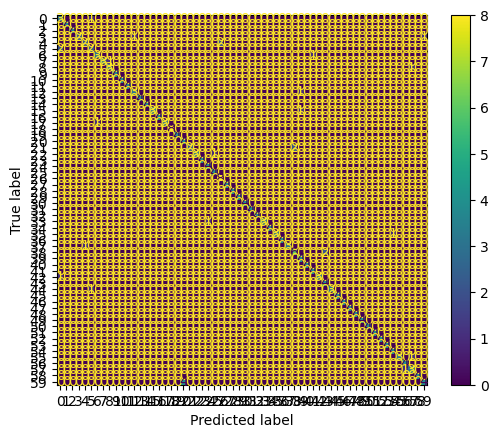

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = metrics.confusion_matrix(test_labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

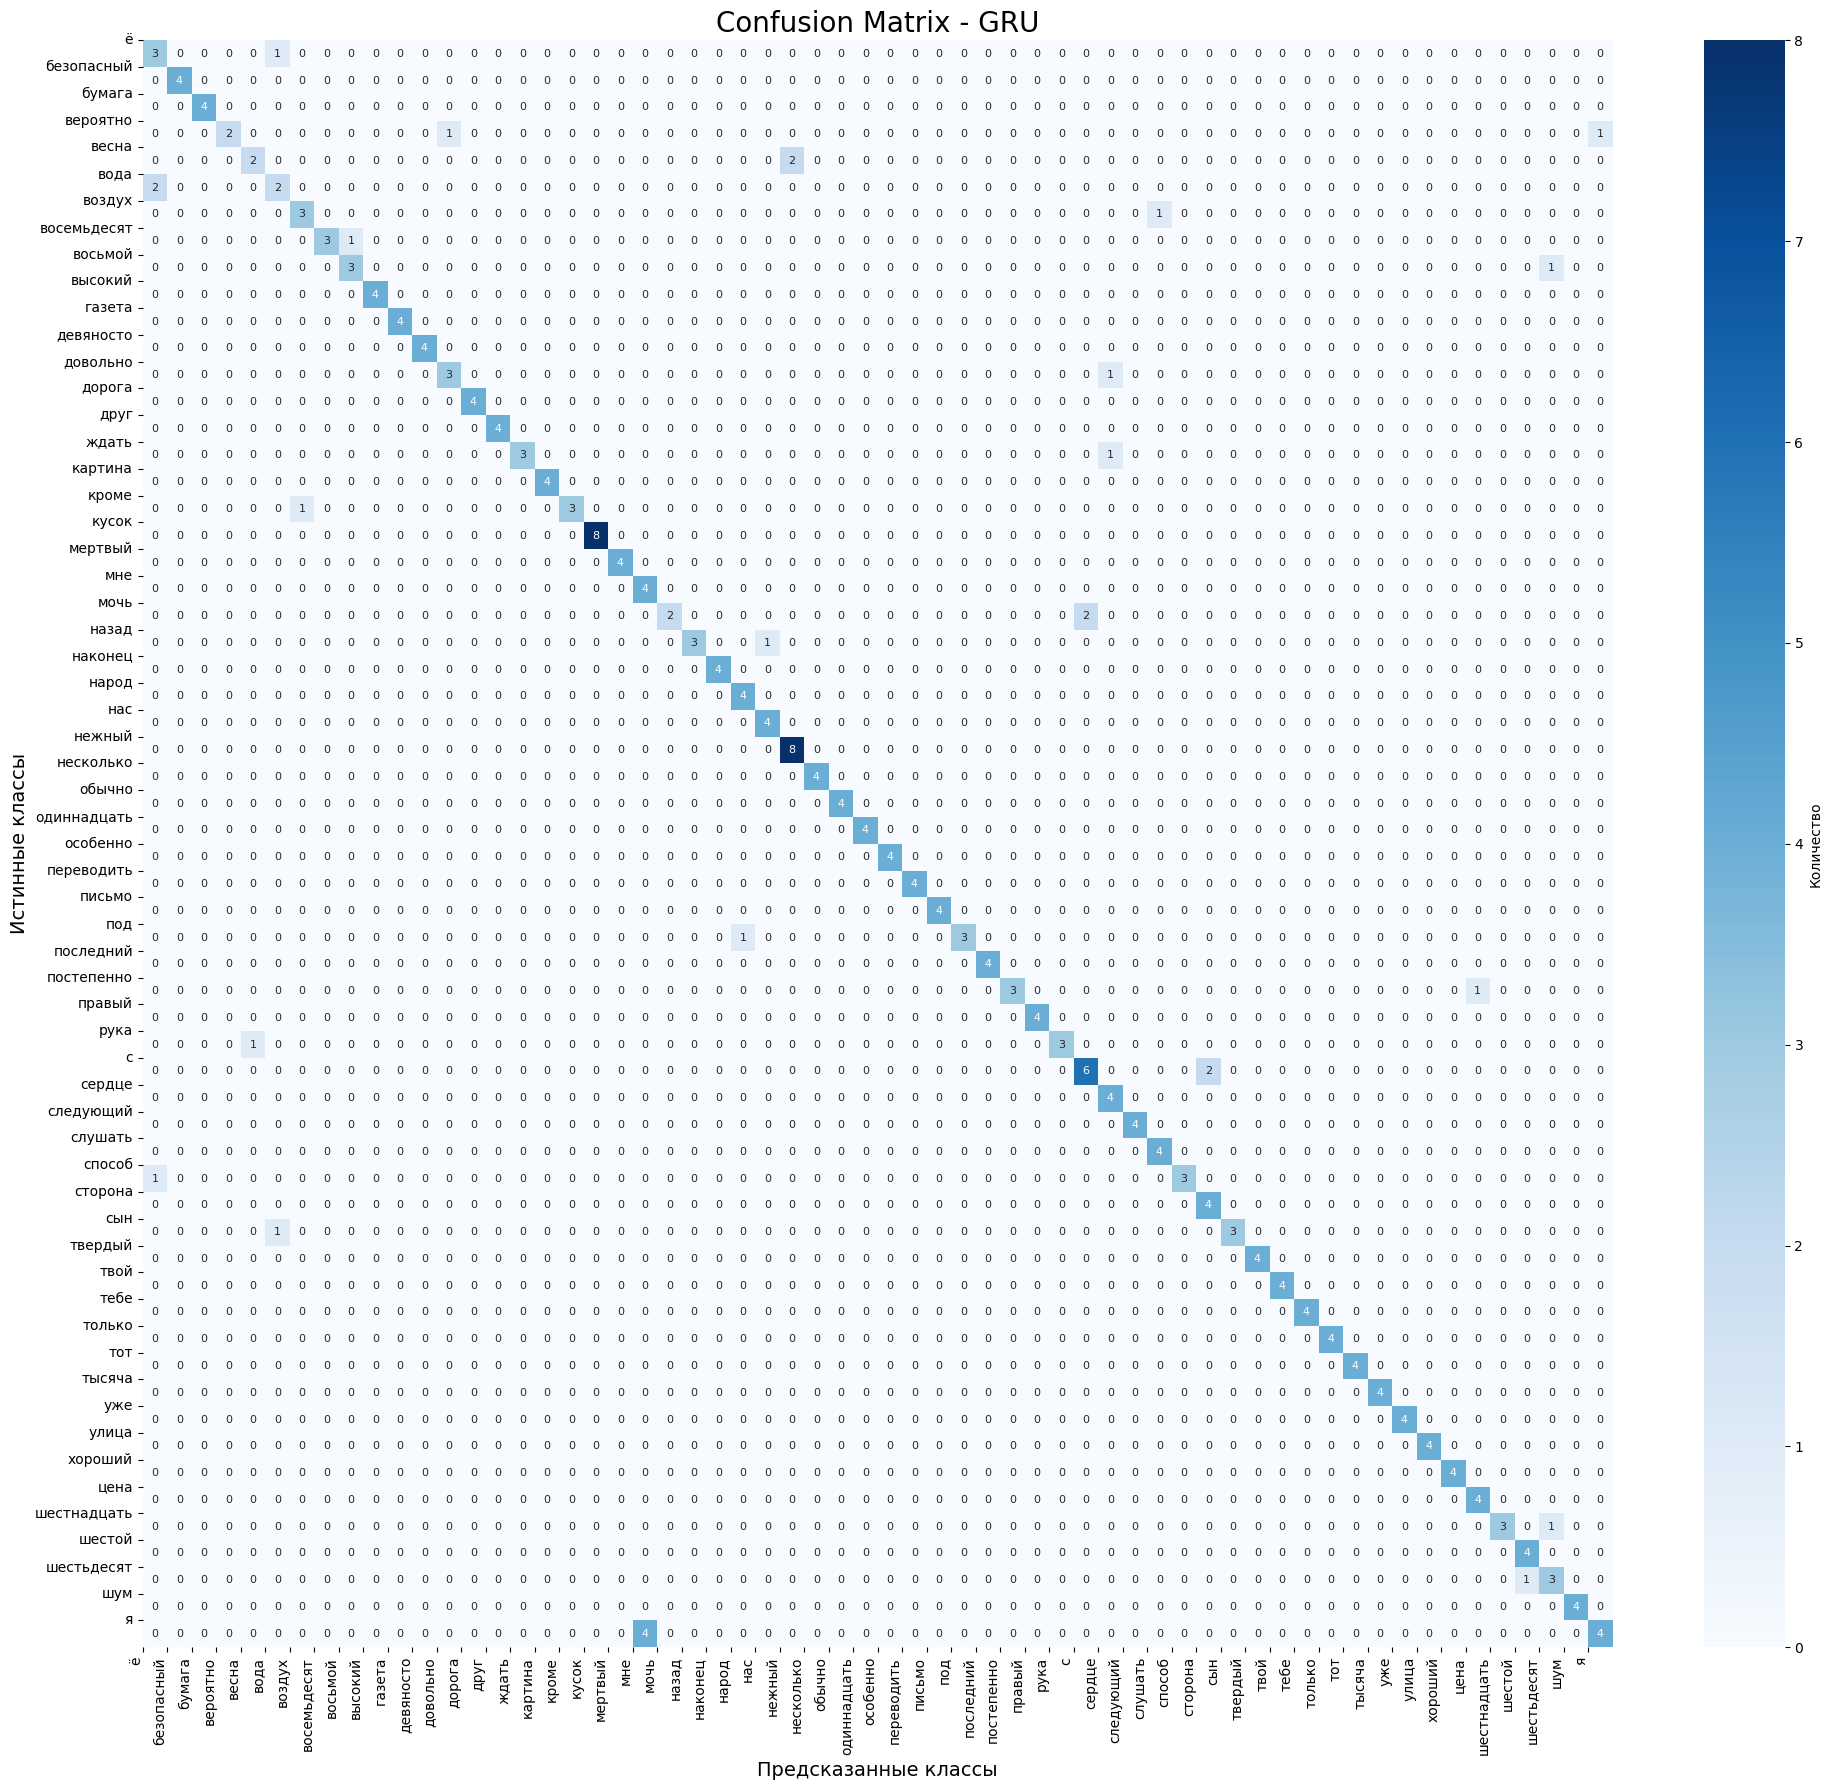

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

plt.figure(figsize=(20, 18))
cm = confusion_matrix(test_labels, predictions)
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            cbar_kws={'label': 'Количество'},
            annot_kws={'size': 8})
plt.title('Confusion Matrix - GRU', fontsize=20)
plt.xlabel('Предсказанные классы', fontsize=14)
plt.ylabel('Истинные классы', fontsize=14)
plt.xticks(range(len(actions)), actions, rotation=90, ha='right')
plt.yticks(range(len(actions)), actions, rotation=0)
plt.tight_layout()
plt.show()

In [19]:
cr = metrics.classification_report(test_labels, predictions, 
                                    target_names=actions, 
                                    digits=3)
print("\nОтчет о классификации:")
print(cr)


Отчет о классификации:
              precision    recall  f1-score   support

           ё      0.500     0.750     0.600         4
  безопасный      1.000     1.000     1.000         4
      бумага      1.000     1.000     1.000         4
    вероятно      1.000     0.500     0.667         4
       весна      0.667     0.500     0.571         4
        вода      0.500     0.500     0.500         4
      воздух      0.750     0.750     0.750         4
 восемьдесят      1.000     0.750     0.857         4
     восьмой      0.750     0.750     0.750         4
     высокий      1.000     1.000     1.000         4
      газета      1.000     1.000     1.000         4
   девяносто      1.000     1.000     1.000         4
    довольно      0.750     0.750     0.750         4
      дорога      1.000     1.000     1.000         4
        друг      1.000     1.000     1.000         4
       ждать      1.000     0.750     0.857         4
     картина      1.000     1.000     1.000         4
   

In [ ]:
model.save(output_model_path)

class_mapping = {i: word for i, word in enumerate(actions)}
np.save('class_mapping.npy', class_mapping)

with open('class_mapping.txt', 'w', encoding='utf-8') as f:
    for i, word in enumerate(actions):
        f.write(f"{i}: {word}\n")
